In [107]:
# Pandas is used for loading, cleaning, manipulating,
# and analyzing structured datasets (tables).
import pandas as pd

# NumPy is used for numerical computations,
# mathematical operations, and working with arrays.
import numpy as np

# Matplotlib is used to create basic charts and graphs.
import matplotlib.pyplot as plt

# Seaborn is built on top of Matplotlib and is used
# for creating attractive statistical visualizations.
import seaborn as sns

# Ignore unnecessary warning messages to keep
# the notebook output clean and readable.
import warnings
warnings.filterwarnings("ignore")

In [108]:
!pip install matplotlib

In [109]:
# Read the customer analytics dataset from the CSV file.
# The dataset is stored in the local system.

my_data = pd.read_csv(
    r"C:\Users\mumma\OneDrive\Desktop\learn tracker\data\archive (2)\customer_analytics 1.csv"
)
my_data


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89
...,...,...,...,...
995,02b2ee0aa7ac4b3db5463ec3863ff8f7,162,1,34.13
996,02b3bd80b9721b83c5b155ace3feede9,129,1,110.41
997,02b3c998830ee93e9edb49fd91aeae4c,236,1,60.00
998,02b3eb3619fdcba4c5a8e5d9ad6c97f2,442,1,117.13


In [110]:
# Display the first five rows to verify that the dataset
# has been loaded successfully.
my_data.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [111]:
# Display the last five rows to verify that the dataset
my_data.tail()

,customer_unique_id,Recency,Frequency,Monetary
995,02b2ee0aa7ac4b3db5463ec3863ff8f7,162,1,34.13
996,02b3bd80b9721b83c5b155ace3feede9,129,1,110.41
997,02b3c998830ee93e9edb49fd91aeae4c,236,1,60.00
998,02b3eb3619fdcba4c5a8e5d9ad6c97f2,442,1,117.13
999,02b6ef845021b8fefe19c8d200f3ee06,197,1,2024.31


In [112]:
# Display information about the dataset.
# It shows: Number of rows and columns, Column names, Data types, Non-null values, Memory usage
my_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  1000 non-null   str    
 1   Recency             1000 non-null   int64  
 2   Frequency           1000 non-null   int64  
 3   Monetary            1000 non-null   float64
dtypes: float64(1), int64(2), str(1)
memory usage: 62.6 KB


In [113]:
# Display statistical summary of all numerical columns.
# It includes:
# Count, Mean, Standard Deviation, Minimum,
# 25%, 50%, 75% and Maximum values.
my_data.describe

<bound method NDFrame.describe of                    customer_unique_id  Recency  Frequency  Monetary
0    0000366f3b9a7992bf8c76cfdf3221e2      160          1    141.90
1    0000b849f77a49e4a4ce2b2a4ca5be3f      163          1     27.19
2    0000f46a3911fa3c0805444483337064      586          1     86.22
3    0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62
4    0004aac84e0df4da2b147fca70cf8255      337          1    196.89
..                                ...      ...        ...       ...
995  02b2ee0aa7ac4b3db5463ec3863ff8f7      162          1     34.13
996  02b3bd80b9721b83c5b155ace3feede9      129          1    110.41
997  02b3c998830ee93e9edb49fd91aeae4c      236          1     60.00
998  02b3eb3619fdcba4c5a8e5d9ad6c97f2      442          1    117.13
999  02b6ef845021b8fefe19c8d200f3ee06      197          1   2024.31

[1000 rows x 4 columns]>

In [114]:
# Display the shape of the dataset
# (Number of Rows, Number of Columns)
my_data.shape

(1000, 4)

In [115]:
# Display all column names
my_data.columns

Index(['customer_unique_id', 'Recency', 'Frequency', 'Monetary'], dtype='str')

In [116]:
# Check missing values
print(my_data.isnull().sum())

# Remove duplicate records
my_data = my_data.drop_duplicates()

# Handle missing values
my_data = my_data.fillna(0)  # or use mean/median depending on the column

# Check data types
print(my_data.dtypes)


customer_unique_id    0
Recency               0
Frequency             0
Monetary              0
dtype: int64
customer_unique_id        str
Recency                 int64
Frequency               int64
Monetary              float64
dtype: object


## SELECT FEATURES FOR CUSTOMER ANALYSIS

In [117]:
# Select the three RFM (Recency, Frequency, Monetary) features
# from the dataset. These features represent customer behavior
# and will be used for customer segmentation and machine learning.
X = my_data[['Recency', 'Frequency', 'Monetary']]

In [118]:
from sklearn.preprocessing import StandardScaler

# Select RFM features
rfm_features = my_data[['Recency', 'Frequency', 'Monetary']]

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert scaled data back to DataFrame
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

print(rfm_scaled_df.head())

    Recency  Frequency  Monetary
0 -0.831380  -0.160128 -0.094784
1 -0.811740  -0.160128 -0.561704
2  1.957453  -0.160128 -0.321426
3  0.543397  -0.160128 -0.494826
4  0.327360  -0.160128  0.129049


# Determine the Optimal Number of Clusters using Elbow Method

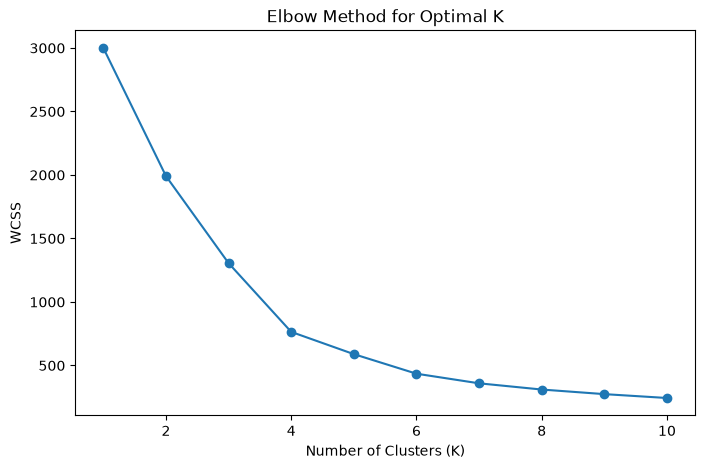

In [119]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS for different values of K
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

Generate final K-Means clusters 'Champions', 'Potential Loyalists', 'At Risk', 'Lost'
Visualize clusters using a 3D scatter plot in Matplotlib/Seaborn
Export segmented customer list for marketing team review

# CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING

In [120]:
from sklearn.cluster import KMeans

# Train the K-Means model using 4 clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Assign each customer to a cluster
my_data['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Map cluster numbers to business-friendly segment names
cluster_mapping = {
    0: 'Potential Loyalists',
    1: 'Lost',
    2: 'Champions',
    3: 'At Risk'
}

# Create a new column with customer segment names
my_data['Segment'] = my_data['Cluster'].map(cluster_mapping)

# Display the first five customer segments
print(my_data[['customer_unique_id', 'Segment']].head())

# Display the number of customers in each segment
print("\nCustomer Segment Distribution:")
print(my_data['Segment'].value_counts())

                 customer_unique_id              Segment
0  0000366f3b9a7992bf8c76cfdf3221e2  Potential Loyalists
1  0000b849f77a49e4a4ce2b2a4ca5be3f  Potential Loyalists
2  0000f46a3911fa3c0805444483337064                 Lost
3  0000f6ccb0745a6a4b88665a16c9f078                 Lost
4  0004aac84e0df4da2b147fca70cf8255                 Lost

Customer Segment Distribution:
Segment
Potential Loyalists    546
Lost                   419
Champions               25
At Risk                 10
Name: count, dtype: int64


# 3D VISUALIZATION OF CUSTOMER CLUSTERS

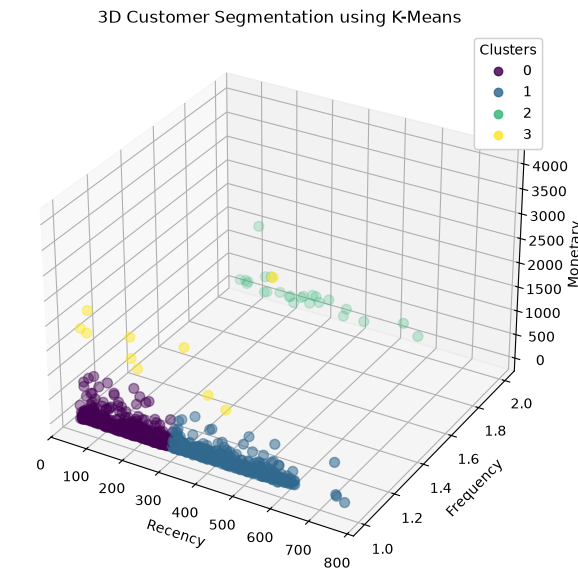

In [121]:
# Import the 3D plotting toolkit
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot customers based on Recency, Frequency and Monetary values
scatter = ax.scatter(
    my_data['Recency'],
    my_data['Frequency'],
    my_data['Monetary'],
    c=my_data['Cluster'],
    cmap='viridis',
    s=50,
    alpha=0.8
)

# Add axis labels
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

# Add chart title
ax.set_title('3D Customer Segmentation using K-Means')

# Add cluster legend
legend = ax.legend(
    *scatter.legend_elements(),
    title="Clusters"
)
ax.add_artist(legend)

plt.show()

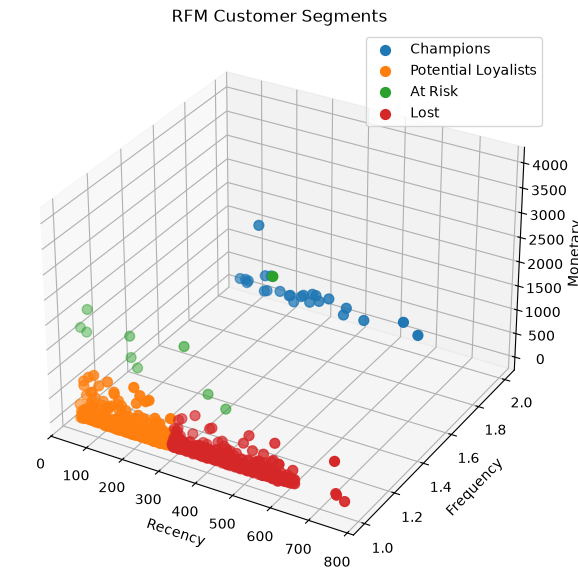

In [122]:
import seaborn as sns

segment_colors = {
    'Champions': 'green',
    'Potential Loyalists': 'blue',
    'At Risk': 'orange',
    'Lost': 'red'
}

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for segment, color in segment_colors.items():
    subset = my_data[my_data['Segment'] == segment]

    ax.scatter(
        subset['Recency'],
        subset['Frequency'],
        subset['Monetary'],
        label=segment,
        s=50
    )

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('RFM Customer Segments')
ax.legend()

plt.show()

In [123]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


# EXPORT CUSTOMER SEGMENTATION RESULTS

In [124]:
# Save the customer dataset with Cluster and Segment columns
# to a CSV file for future analysis and Power BI reporting.
my_data.to_csv(
    "segmented_customers.csv",
    index=False
)

print("segmentation results exported successfully!")

segmentation results exported successfully!


In [125]:
# Select only the columns required for marketing analysis
# and dashboard reporting.
marketing_list = my_data[
    [
        'customer_unique_id',
        'Recency',
        'Frequency',
        'Monetary',
        'Segment'
    ]
]

# Export the marketing dataset to a CSV file.
marketing_list.to_csv(
    "marketing_customer_segments.csv",
    index=False
)

print("Marketing customer segment dataset exported successfully!")

Marketing customer segment dataset exported successfully!


# VERIFY THE EXPORTED MARKETING DATASET

In [126]:
# Load the exported marketing dataset to verify
# that it was saved correctly.
exported_file = pd.read_csv("marketing_customer_segments.csv")

# Display the first five records.
print(exported_file.head())

# Display the number of rows and columns.
print("\nDataset Shape:", exported_file.shape)

                 customer_unique_id  Recency  Frequency  Monetary  \
0  0000366f3b9a7992bf8c76cfdf3221e2      160          1    141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      163          1     27.19   
2  0000f46a3911fa3c0805444483337064      586          1     86.22   
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62   
4  0004aac84e0df4da2b147fca70cf8255      337          1    196.89   

               Segment  
0  Potential Loyalists  
1  Potential Loyalists  
2                 Lost  
3                 Lost  
4                 Lost  

Dataset Shape: (1000, 5)


In [127]:
import os
print(os.getcwd())

C:\Users\mumma\project DA


# LOAD OLIST ORDERS DATASET

In [128]:
# Load the orders dataset containing customer order details.
orders = pd.read_csv("olist_orders_dataset.csv")

# Display the first five records to verify the data.
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [129]:
import os

print(os.getcwd())      # Current folder
print(os.listdir())     # Files in that folder

C:\Users\mumma\project DA
['.ipynb_checkpoints', 'customer_churn_scores.csv', 'dashboard_dataset.csv', 'EDA analysis.ipynb', 'marketing_customer_segments.csv', 'monthly_retention.csv', 'olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv', 'random_forest_churn_model.pkl', 'segmented_customers.csv', 'segment_statistics.csv', 'top10_states.csv']


In [130]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'customer_churn_scores.csv', 'dashboard_dataset.csv', 'EDA analysis.ipynb', 'marketing_customer_segments.csv', 'monthly_retention.csv', 'olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv', 'random_forest_churn_model.pkl', 'segmented_customers.csv', 'segment_statistics.csv', 'top10_states.csv']


In [131]:
print(orders.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')


# CONVERT DATE COLUMNS TO DATETIME FORMAT

In [132]:
# Convert order purchase date to datetime format.
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# Convert actual customer delivery date to datetime format.
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

# Convert estimated delivery date to datetime format.
orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

# Verify the updated data types.
orders[
    [
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
].dtypes

order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

# CALCULATE SHIPPING DELAY

In [133]:
# Calculate the number of days between the actual delivery date
# and the estimated delivery date.
#
# Positive Value  -> Order delivered late
# Zero            -> Delivered on time
# Negative Value  -> Delivered before the estimated date

orders['shipping_delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.days

# Display the first five records to verify the calculation.
orders[['shipping_delay_days']].head()

,shipping_delay_days
0,-8.0
1,-6.0
2,-18.0
3,-13.0
4,-10.0


# CREATE CUSTOMER CHURN LABEL

In [134]:
# Get the most recent purchase date in the dataset.
# This will be used as the reference date.
reference_date = orders['order_purchase_timestamp'].max()

# Find each customer's most recent purchase.
customer_churn = (
    orders.groupby('customer_id')['order_purchase_timestamp']
    .max()
    .reset_index()
)

# Calculate the number of inactive days for each customer.
customer_churn['days_inactive'] = (
    reference_date -
    customer_churn['order_purchase_timestamp']
).dt.days

# Create the churn label.
# Customers inactive for more than 90 days are marked as churned.
customer_churn['churn'] = (
    customer_churn['days_inactive'] > 90
).astype(int)

# Display the first five records.
customer_churn.head()

,customer_id,order_purchase_timestamp,days_inactive,churn
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,337,1
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,458,1
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,596,1
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,427,1
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,198,1


# CALCULATE AVERAGE SHIPPING DELAY FOR EACH CUSTOMER

In [135]:
# Calculate the average shipping delay for every customer.
customer_delay = (
    orders.groupby('customer_id')['shipping_delay_days']
    .mean()
    .reset_index()
)

# Display the first five records.
customer_delay.head()

,customer_id,shipping_delay_days
0,00012a2ce6f8dcda20d059ce98491703,-6.0
1,000161a058600d5901f007fab4c27140,-10.0
2,0001fd6190edaaf884bcaf3d49edf079,-16.0
3,0002414f95344307404f0ace7a26f1d5,-1.0
4,000379cdec625522490c315e70c7a9fb,-5.0


# MERGE CUSTOMER CHURN DATA WITH SHIPPING DELAY

In [136]:
# Merge churn information with the average shipping delay
# for each customer using the customer_id.
churn_data = pd.merge(
    customer_churn,
    customer_delay,
    on='customer_id',
    how='left'
)

# Display the first five records of the merged dataset.
churn_data.head()

,customer_id,order_purchase_timestamp,days_inactive,churn,shipping_delay_days
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,337,1,-6.0
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,458,1,-10.0
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,596,1,-16.0
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,427,1,-1.0
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,198,1,-5.0


# ANALYZE THE RELATIONSHIP BETWEEN SHIPPING DELAY AND CHURN

In [137]:
from scipy.stats import pearsonr

# Calculate the Pearson correlation coefficient and p-value
# between average shipping delay and customer churn.
corr, p_value = pearsonr(
    churn_data['shipping_delay_days'].fillna(0),
    churn_data['churn']
)

# Display the correlation results.
print(f"Pearson Correlation: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson Correlation: -0.0916
P-value: 0.0000


# CALCULATE DAYS SINCE THE LAST CUSTOMER ORDER

In [138]:
# Find the latest purchase date in the dataset.
reference_date = orders['order_purchase_timestamp'].max()

# Get the most recent purchase date for each customer.
customer_last_order = (
    orders.groupby('customer_id')['order_purchase_timestamp']
    .max()
    .reset_index()
)

# Calculate the number of days since the customer's last purchase.
customer_last_order['days_since_last_order'] = (
    reference_date -
    customer_last_order['order_purchase_timestamp']
).dt.days

# Display the first five records.
customer_last_order.head()

,customer_id,order_purchase_timestamp,days_since_last_order
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,337
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,458
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,596
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,427
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,198


# LOAD CUSTOMER REVIEWS AND MERGE WITH ORDERS

In [139]:
# Load the customer reviews dataset.
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

# Merge the orders dataset with customer reviews
# using the common 'order_id' column.
orders_reviews = pd.merge(
    orders,
    reviews,
    on="order_id",
    how="left"
)

# Display the first five records of the merged dataset.
orders_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,shipping_delay_days,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


# CHECK CHURN CLASS DISTRIBUTION

In [140]:
# Display the number of churned and non-churned customers.
churn_data['churn'].value_counts()

churn
1    89652
0     9789
Name: count, dtype: int64

# BALANCE THE DATASET USING SMOTE

In [141]:
from imblearn.over_sampling import SMOTE

# Select required columns
X = churn_data[['shipping_delay_days']].copy()
y = churn_data['churn']

# Replace missing values with the median shipping delay
# (Median is preferred over 0 because it is less affected by outliers)
X['shipping_delay_days'] = X['shipping_delay_days'].fillna(
    X['shipping_delay_days'].median()
)

# Create SMOTE object
smote = SMOTE(random_state=42)

# Balance the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

# Display the balanced class distribution
print("Class Distribution After SMOTE:")
print(y_resampled.value_counts())

Class Distribution After SMOTE:
churn
1    89652
0    89652
Name: count, dtype: int64


In [142]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [143]:
import imblearn
print(imblearn.__version__)

0.14.2


# CHECK CHURN CLASS DISTRIBUTION

In [144]:
# Display the number of churned and non-churned customers
print("Churn Class Distribution:")
print(churn_data['churn'].value_counts())

# Display the percentage distribution
print("\nPercentage Distribution:")
print((churn_data['churn'].value_counts(normalize=True) * 100).round(2))

Churn Class Distribution:
churn
1    89652
0     9789
Name: count, dtype: int64

Percentage Distribution:
churn
1    90.16
0     9.84
Name: proportion, dtype: float64


# BALANCE THE DATASET USING SMOTE

In [145]:
from imblearn.over_sampling import SMOTE

# Select feature(s) and target variable
X = churn_data[['shipping_delay_days']].copy()
y = churn_data['churn']

# Replace missing values before applying SMOTE
X['shipping_delay_days'] = X['shipping_delay_days'].fillna(
    X['shipping_delay_days'].median()
)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Display the balanced class distribution
print("\nClass Distribution After SMOTE:")
print(y_resampled.value_counts())


Class Distribution After SMOTE:
churn
1    89652
0    89652
Name: count, dtype: int64


In [146]:
print(X.shape)
print(y.shape)
print(X.isnull().sum())
print(y.isnull().sum())
print(y.value_counts())

(99441, 1)
(99441,)
shipping_delay_days    0
dtype: int64
0
churn
1    89652
0     9789
Name: count, dtype: int64


# HANDLE MISSING VALUES AND APPLY SMOTE

In [147]:
from imblearn.over_sampling import SMOTE

# Replace missing values before applying SMOTE
X = X.fillna(0)

# Create the SMOTE object
smote = SMOTE(random_state=42)

# Balance the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

# Display the balanced class distribution
print("Class Distribution After SMOTE:")
print(y_resampled.value_counts())

Class Distribution After SMOTE:
churn
1    89652
0    89652
Name: count, dtype: int64


In [148]:
print(y.value_counts())

churn
1    89652
0     9789
Name: count, dtype: int64


In [149]:
smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [150]:
print(orders.head())
print(orders.columns)

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [151]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
Axes3D                   type                      <class 'mpl_toolkits.mplot3d.axes3d.Axes3D'>
GridSearchCV             ABCMeta                   <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
KMeans                   ABCMeta                   <class 'sklearn.cluster._kmeans.KMeans'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SMOTE                    ABCMeta                   <class 'imblearn.over_sam<...>pling._smote.base.SMOTE'>
StandardScaler           type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                        DataFrame                 Shape: (99441, 1)
X_resampled              DataFrame                 Shape: (179304, 1)
X_test                   DataFrame                 Shape: (200, 3)
X_train                  DataFrame                 Shape

In [152]:
print(orders.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'shipping_delay_days'],
      dtype='str')


# CREATE CUSTOMER CHURN DATASET

In [153]:
# Find the most recent purchase date in the dataset.
# This will be used as the reference date for churn calculation.
reference_date = orders['order_purchase_timestamp'].max()

# Get the last purchase date for each customer.
customer_churn = (
    orders.groupby('customer_id')['order_purchase_timestamp']
    .max()
    .reset_index()
)

# Calculate the number of days since each customer's last purchase.
customer_churn['days_since_last_order'] = (
    reference_date -
    customer_churn['order_purchase_timestamp']
).dt.days

# Create the churn label.
# Customers with no purchases for more than 90 days
# are considered churned.
customer_churn['churn'] = (
    customer_churn['days_since_last_order'] > 90
).astype(int)

# Display the first five records.
customer_churn.head()

,customer_id,order_purchase_timestamp,days_since_last_order,churn
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,337,1
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,458,1
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,596,1
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,427,1
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,198,1


In [154]:
print(customer_churn['churn'].value_counts())

churn
1    89652
0     9789
Name: count, dtype: int64


# GENERATE SUMMARY STATISTICS FOR EACH CUSTOMER SEGMENT

In [155]:
# Calculate the average, minimum, and maximum values
# of Recency, Frequency, and Monetary for each customer segment.
segment_summary = (
    my_data.groupby('Segment')
    .agg({
        'Recency': ['mean', 'min', 'max'],
        'Frequency': ['mean', 'min', 'max'],
        'Monetary': ['mean', 'min', 'max']
    })
    .round(2)
)

# Display the summary statistics.
segment_summary

Recency           Frequency         Monetary           \
                       mean  min  max      mean min max     mean      min   
Segment                                                                     
At Risk              261.40   61  578       1.0   1   1  1975.18  1150.54   
Champions            242.12   65  575       2.0   2   2   289.79    75.31   
Lost                 434.34  305  764       1.0   1   1   137.43    16.22   
Potential Loyalists  176.45   51  308       1.0   1   1   147.63    16.78   

                              
                         max  
Segment                       
At Risk              4016.91  
Champions            1510.38  
Lost                  821.35  
Potential Loyalists  1005.81

In [156]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'customer_churn_scores.csv', 'dashboard_dataset.csv', 'EDA analysis.ipynb', 'marketing_customer_segments.csv', 'monthly_retention.csv', 'olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv', 'random_forest_churn_model.pkl', 'segmented_customers.csv', 'segment_statistics.csv', 'top10_states.csv']


# LOAD CUSTOMER REVIEWS AND MERGE WITH ORDER DATA

In [157]:
# Load the customer reviews dataset.
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

# Merge the orders dataset with the reviews dataset
# using 'order_id' as the common key.
orders_reviews = pd.merge(
    orders,
    reviews,
    on="order_id",
    how="left"
)

# Display the first five records to verify the merge.
orders_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,shipping_delay_days,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


# CHECK CHURN CLASS DISTRIBUTION

In [158]:
# Display the number of churned and non-churned customers.
customer_churn['churn'].value_counts()

churn
1    89652
0     9789
Name: count, dtype: int64

# BALANCE THE CHURN DATASET USING SMOTE

In [159]:
from imblearn.over_sampling import SMOTE

# Select feature and target variable
X = customer_churn[['days_since_last_order']]
y = customer_churn['churn']

# Create the SMOTE object
smote = SMOTE(
    random_state=42,
    k_neighbors=2
)

# Apply SMOTE
X_resampled, y_resampled = smote.fit_resample(X, y)

# Display the balanced class distribution
y_resampled.value_counts()

churn
1    89652
0    89652
Name: count, dtype: int64

In [160]:
segment_stats = my_data.groupby('Segment').agg({
    'Recency': ['mean', 'median', 'min', 'max'],
    'Frequency': ['mean', 'median', 'min', 'max'],
    'Monetary': ['mean', 'median', 'min', 'max']
}).round(2)

In [161]:
print(my_data['Segment'].value_counts())

Segment
Potential Loyalists    546
Lost                   419
Champions               25
At Risk                 10
Name: count, dtype: int64


In [162]:
payments = pd.read_csv("olist_order_payments_dataset.csv")

In [163]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'customer_churn_scores.csv', 'dashboard_dataset.csv', 'EDA analysis.ipynb', 'marketing_customer_segments.csv', 'monthly_retention.csv', 'olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv', 'random_forest_churn_model.pkl', 'segmented_customers.csv', 'segment_statistics.csv', 'top10_states.csv']


In [164]:
payments = pd.read_csv("olist_order_payments_dataset.csv")
print(payments.head())

                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  


In [165]:
segment_stats.to_csv("segment_statistics.csv")

In [166]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'customer_churn_scores.csv', 'dashboard_dataset.csv', 'EDA analysis.ipynb', 'marketing_customer_segments.csv', 'monthly_retention.csv', 'olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv', 'random_forest_churn_model.pkl', 'segmented_customers.csv', 'segment_statistics.csv', 'top10_states.csv']


In [167]:
print(os.listdir())

['.ipynb_checkpoints', 'customer_churn_scores.csv', 'dashboard_dataset.csv', 'EDA analysis.ipynb', 'marketing_customer_segments.csv', 'monthly_retention.csv', 'olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv', 'random_forest_churn_model.pkl', 'segmented_customers.csv', 'segment_statistics.csv', 'top10_states.csv']


In [168]:
payments = pd.read_csv("olist_order_payments_dataset.csv")

print(payments.head())

                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  


# CREATE CUSTOMER CHURN DATASET

In [169]:
# Find the latest purchase date in the dataset.
# This is used as the reference date for calculating customer inactivity.
reference_date = orders['order_purchase_timestamp'].max()

# Find the last purchase date for each customer.
customer_churn = (
    orders.groupby('customer_id')['order_purchase_timestamp']
    .max()
    .reset_index()
)

# Calculate the number of days since the customer's last purchase.
customer_churn['days_since_last_order'] = (
    reference_date -
    customer_churn['order_purchase_timestamp']
).dt.days

# Create the churn label.
# Customers inactive for more than 90 days are marked as churned.
customer_churn['churn'] = (
    customer_churn['days_since_last_order'] > 90
).astype(int)

# Display the first five records.
customer_churn.head()

,customer_id,order_purchase_timestamp,days_since_last_order,churn
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,337,1
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,458,1
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,596,1
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,427,1
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,198,1


# MERGE ORDER AND PAYMENT INFORMATION

In [170]:
# Combine customer order information with payment type details
# using 'order_id' as the common key.

payment_data = pd.merge(
    orders[['order_id', 'customer_id']],
    payments[['order_id', 'payment_type']],
    on='order_id',
    how='inner'
)

# Display the first five records to verify the merge.
payment_data.head()

,order_id,customer_id,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,credit_card
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,voucher
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,voucher
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,boleto
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,credit_card


# MERGE PAYMENT INFORMATION WITH CUSTOMER CHURN DATA

In [171]:
# Combine payment information with customer churn labels
# using 'customer_id' as the common key.

payment_churn = pd.merge(
    payment_data,
    customer_churn[['customer_id', 'churn']],
    on='customer_id',
    how='left'
)

# Display the first five records to verify the merge.
payment_churn.head()

,order_id,customer_id,payment_type,churn
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,credit_card,1
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,voucher,1
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,voucher,1
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,boleto,0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,credit_card,0


# VISUALIZE CHURN DISTRIBUTION BY PAYMENT METHOD

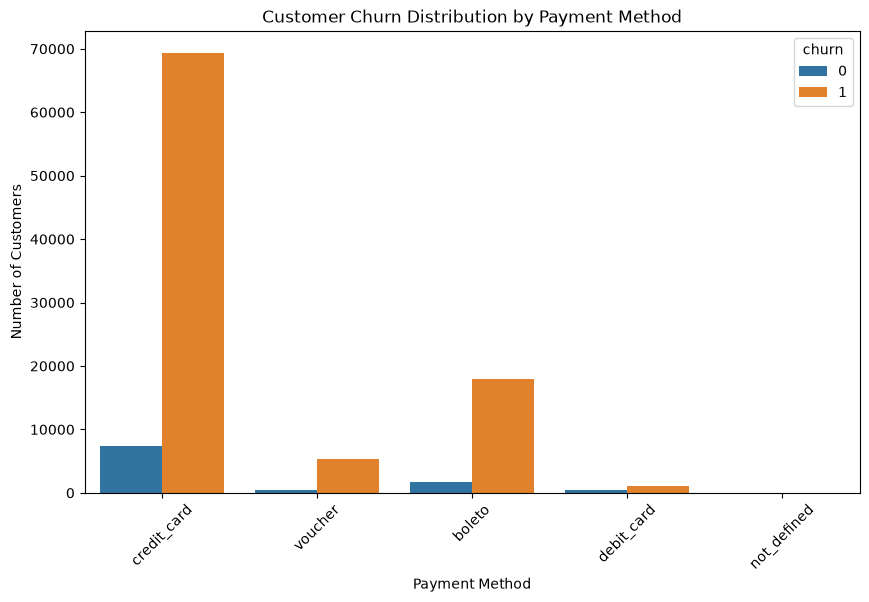

In [172]:
# Create a figure for the visualization.
plt.figure(figsize=(10, 6))

# Plot the number of churned and active customers
# for each payment method.
sns.countplot(
    data=payment_churn,
    x='payment_type',
    hue='churn'
)

# Add chart title and axis labels.
plt.title('Customer Churn Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')

# Rotate x-axis labels for better readability.
plt.xticks(rotation=45)

# Display the chart.
plt.show()

In [173]:
segment_stats.to_csv("segment_statistics.csv")

# CALCULATE MONTHLY ACTIVE CUSTOMERS (RETENTION ANALYSIS)

In [174]:
# Extract the purchase month from the order timestamp.
orders['Month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Count the number of unique active customers in each month.
monthly_retention = (
    orders.groupby('Month')['customer_id']
    .nunique()
    .reset_index()
)

# Rename the columns for better readability.
monthly_retention.columns = [
    'Month',
    'Active_Customers'
]

# Export the monthly retention data.
monthly_retention.to_csv(
    "monthly_retention.csv",
    index=False
)

# Display the first five records.
monthly_retention.head()

,Month,Active_Customers
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


# MERGE CUSTOMER, ORDER, AND SEGMENT DATA

In [175]:
# Load datasets (only if they are not already loaded).
customers = pd.read_csv("olist_customers_dataset.csv")
segments = pd.read_csv("segmented_customers.csv")

# Merge orders with customer information.
merged = orders.merge(
    customers,
    on="customer_id",
    how="inner"
)

# Merge the result with customer segmentation data.
merged = merged.merge(
    segments,
    on="customer_unique_id",
    how="inner"
)

# Display the first five records.
merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,shipping_delay_days,Month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,Recency,Frequency,Monetary,Cluster,Segment
0,77e9941864fc840be8e4b1ba5347c0f7,3135962ee745ef39b85576df7ddbaa99,delivered,2018-08-03 08:59:39,2018-08-03 09:31:36,2018-08-03 10:10:00,2018-08-17 00:49:41,2018-08-27,-10.0,2018-08,00b2ca23369b68c4d4105ecea9c0cb93,62970,alto santo,CE,75,1,103.27,0,Potential Loyalists
1,32bda40452bf0485c310bca24eb53886,ebfb3f2e532c37d5a959ded000c9f603,delivered,2018-07-06 18:16:06,2018-07-10 08:45:18,2018-07-11 11:51:00,2018-07-16 13:11:06,2018-07-27,-11.0,2018-07,01593b828c6e7c516ed078a4820ab9b2,14875,jaboticabal,SP,103,1,44.87,0,Potential Loyalists
2,b693d6c35867fa1937455e04f2547df2,eec909ab0da04f0d3e92f898c6994d37,delivered,2017-05-11 09:13:17,2017-05-11 09:25:21,2017-05-11 10:09:25,2017-05-16 09:42:08,2017-05-31,-15.0,2017-05,00dd4390a8e8ad7a126e8331decc49ce,20540,rio de janeiro,RJ,524,1,109.31,1,Lost
3,eba75422c6a2414d3cd8289123e64200,d7c4d8b45b0a33ff6df7a3950800d4e8,delivered,2018-07-30 18:25:18,2018-07-31 03:55:21,2018-07-31 13:55:00,2018-08-07 14:21:45,2018-08-24,-17.0,2018-07,0255fc149c1f191319c8c431479e5d8c,72830,luziania,GO,79,1,140.67,0,Potential Loyalists
4,5f69f6bf68dce110479aa0bb515b47c8,4cd274ce8ba240b1cff6480fa9911df1,delivered,2017-11-26 11:20:27,2017-11-26 11:31:40,2017-11-27 16:36:45,2017-11-30 13:08:44,2017-12-12,-12.0,2017-11,01daeb09de8f07882ccd4319ffbc4693,9415,ribeirao pires,SP,325,1,38.72,1,Lost


# ANALYZE REVENUE BY CUSTOMER STATE

In [176]:
# Calculate the total revenue generated by customers in each state.
state_revenue = (
    merged.groupby('customer_state')['Monetary']
    .sum()
    .reset_index()
)

# Select the top 10 states based on total revenue.
top10 = (
    state_revenue.sort_values(
        by='Monetary',
        ascending=False
    )
    .head(10)
)

# Export the results for Power BI or further analysis.
top10.to_csv(
    "top10_states.csv",
    index=False
)

# Display the top 10 states.
top10

,customer_state,Monetary
25,SP,72761.73
18,RJ,23054.25
10,MG,19041.15
4,BA,9225.40
22,RS,8961.36
17,PR,6370.75
23,SC,6006.46
7,ES,3505.20
8,GO,3157.88
5,CE,3038.88


In [177]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'customer_churn_scores.csv', 'dashboard_dataset.csv', 'EDA analysis.ipynb', 'marketing_customer_segments.csv', 'monthly_retention.csv', 'olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv', 'random_forest_churn_model.pkl', 'segmented_customers.csv', 'segment_statistics.csv', 'top10_states.csv']


# CREATE DASHBOARD DATASET FOR POWER BI

In [178]:
# Load additional datasets required for dashboard creation.
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

# Merge orders with customer information.
df = orders.merge(
    customers,
    on="customer_id",
    how="inner"
)

# Merge order item details.
df = df.merge(
    order_items,
    on="order_id",
    how="inner"
)

# Merge product information.
df = df.merge(
    products,
    on="product_id",
    how="inner"
)

# Translate Portuguese product category names into English.
df = df.merge(
    translation,
    on="product_category_name",
    how="left"
)

# Export the final dashboard dataset.
df.to_csv(
    "dashboard_dataset.csv",
    index=False
)

# Display the first five rows.
df.head()

# Display the column names.
print(df.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'shipping_delay_days', 'Month', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='str')


# LOAD MARKETING CUSTOMER SEGMENTS DATASET

In [179]:
# Load the customer segmentation dataset generated
# after applying K-Means clustering.
data = pd.read_csv("marketing_customer_segments.csv")

# Display the first five records.
data.head()

,customer_unique_id,Recency,Frequency,Monetary,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,Potential Loyalists
2,0000f46a3911fa3c0805444483337064,586,1,86.22,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,Lost
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,Lost


In [180]:
print(my_data.columns)

Index(['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'Cluster',
       'Segment'],
      dtype='str')


# CREATE CHURN LABEL

In [181]:
# Customers in the "Lost" segment are treated as churned.
data["churn"] = (data["Segment"] == "Lost").astype(int)

print(data["churn"].value_counts())

churn
0    581
1    419
Name: count, dtype: int64


# SELECT FEATURES AND TARGET

In [182]:
X = data[['Recency', 'Frequency', 'Monetary']]
y = data['churn']

# SPLIT DATA INTO TRAINING AND TESTING SETS

In [183]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets.
# The training data is used to train the Random Forest model,
# while the testing data is used to evaluate its performance.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shape of the training and testing datasets.
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (800, 3)
Testing Data Shape  : (200, 3)


# TRAIN RANDOM FOREST CHURN PREDICTION MODEL

In [184]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest classifier.
# The model uses 100 decision trees to classify customers
# as churned or non-churned based on the selected features.
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the Random Forest model using the training dataset.
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


# GENERATE CHURN PREDICTIONS USING THE TRAINED MODEL

In [185]:
# Use the trained Random Forest model to predict
# customer churn for the testing dataset.
y_pred = rf_model.predict(X_test)

print("Customer churn predictions generated successfully.")

Customer churn predictions generated successfully.


# EVALUATE RANDOM FOREST MODEL PERFORMANCE

In [186]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Calculate evaluation metrics using the testing dataset.
print("Model Performance Metrics")
print("-" * 35)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

# Display the detailed classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Display the confusion matrix.
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Model Performance Metrics
-----------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       116
           1       1.00      1.00      1.00        84

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix
[[116   0]
 [  0  84]]


# OPTIMIZE RANDOM FOREST USING GRID SEARCH CROSS-VALIDATION

In [187]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter combinations to test.
# GridSearchCV will evaluate each combination and
# identify the best-performing Random Forest model.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Initialize GridSearchCV with a Random Forest classifier.
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train GridSearchCV to find the best hyperparameter combination.
grid_search.fit(X_train, y_train)

print("Grid Search completed successfully.")

Grid Search completed successfully.


# SELECT THE BEST RANDOM FOREST MODEL

In [188]:
# Display the best hyperparameter combination identified
# by GridSearchCV.
print("Best Hyperparameters:")
print(grid_search.best_params_)

# Display the best average cross-validation accuracy.
print("\nBest Cross-Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")

# Retrieve the best-performing Random Forest model.
best_model = grid_search.best_estimator_

# Generate predictions on the testing dataset
# using the optimized model.
y_pred = best_model.predict(X_test)

# Display the test accuracy of the optimized model.
print("\nOptimized Model Test Accuracy:")
print(f"{accuracy_score(y_test, y_pred):.4f}")

Best Hyperparameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.9925

Optimized Model Test Accuracy:
1.0000


# EVALUATE THE OPTIMIZED RANDOM FOREST MODEL

In [189]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Retrieve the best Random Forest model selected by GridSearchCV.
best_model = grid_search.best_estimator_

# Display the best hyperparameter combination.
print("Best Hyperparameters:")
print(grid_search.best_params_)

# Display the best cross-validation accuracy.
print("\nBest Cross-Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")

# Generate predictions using the optimized model.
y_pred = best_model.predict(X_test)

# Display model evaluation metrics.
print("\nModel Performance Metrics")
print("-" * 35)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

# Display the detailed classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Display the confusion matrix.
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Best Hyperparameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.9925

Model Performance Metrics
-----------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       116
           1       1.00      1.00      1.00        84

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix
[[116   0]
 [  0  84]]


# ANALYZE FEATURE IMPORTANCE OF THE RANDOM FOREST MODEL

Feature Importance
------------------------------
     Feature  Importance
0    Recency    0.945463
2   Monetary    0.032740
1  Frequency    0.021797


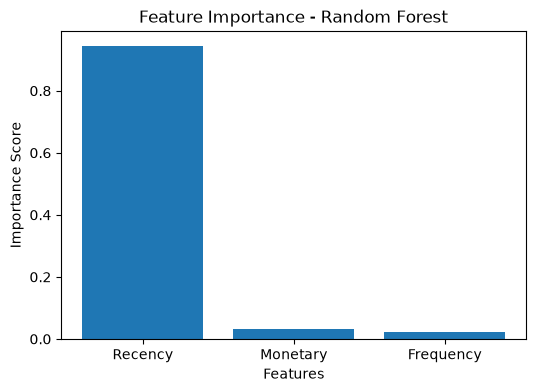

In [190]:
import matplotlib.pyplot as plt

# Create a DataFrame containing each feature and its
# corresponding importance score assigned by the
# optimized Random Forest model.
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

# Sort features in descending order of importance.
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the feature importance values.
print("Feature Importance")
print("-" * 30)
print(importance)

# Visualize feature importance using a bar chart.
plt.figure(figsize=(6, 4))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

# CALCULATE CUSTOMER CHURN PROBABILITY

In [191]:
# Predict the probability of customer churn using the
# optimized Random Forest model.
# The probability ranges from 0 to 1, where:
# 0   = Very low chance of churn
# 1   = Very high chance of churn
churn_probability = best_model.predict_proba(X)[:, 1]

# Add the predicted churn probability as a new column
# in the marketing customer dataset.
data["Likelihood_to_Churn"] = churn_probability

# Display the first five customers along with their
# predicted churn probability.
print("Customer Churn Probability")
print("-" * 35)

print(
    data[
        [
            "customer_unique_id",
            "Recency",
            "Frequency",
            "Monetary",
            "Likelihood_to_Churn"
        ]
    ].head()
)

Customer Churn Probability
-----------------------------------
                 customer_unique_id  Recency  Frequency  Monetary  \
0  0000366f3b9a7992bf8c76cfdf3221e2      160          1    141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      163          1     27.19   
2  0000f46a3911fa3c0805444483337064      586          1     86.22   
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62   
4  0004aac84e0df4da2b147fca70cf8255      337          1    196.89   

   Likelihood_to_Churn  
0             0.013854  
1             0.022132  
2             0.969357  
3             0.966037  
4             0.982556  


# SAVE CUSTOMER CHURN PREDICTION RESULTS

In [192]:
# Save the customer dataset with the predicted
# churn probability scores to a CSV file.
# This file can be used for business reporting,
# customer retention campaigns, or Power BI dashboards.

data.to_csv(
    "customer_churn_scores.csv",
    index=False
)

print("Customer churn prediction dataset saved successfully.")

Customer churn prediction dataset saved successfully.


# SAVE THE TRAINED RANDOM FOREST MODEL

In [193]:
import joblib

# Save the optimized Random Forest model to a file.
# This allows the trained model to be reused later
# without retraining it from scratch.
joblib.dump(
    best_model,
    "random_forest_churn_model.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


# LOAD THE SAVED RANDOM FOREST MODEL

In [194]:
import joblib

# Load the previously saved Random Forest model.
# This allows the trained model to be reused for
# future predictions without retraining.
loaded_model = joblib.load(
    "random_forest_churn_model.pkl"
)

print("Random Forest model loaded successfully.")

Random Forest model loaded successfully.


# VERIFY THE SAVED RANDOM FOREST MODEL

In [195]:
# Use the loaded Random Forest model to predict
# customer churn for the testing dataset.
prediction = loaded_model.predict(X_test)

# Calculate the accuracy of the loaded model.
loaded_model_accuracy = accuracy_score(y_test, prediction)

# Display the verification result.
print("Loaded Model Accuracy")
print("-" * 30)
print(f"Accuracy : {loaded_model_accuracy:.4f}")

print("\nThe saved model was loaded and verified successfully.")

Loaded Model Accuracy
------------------------------
Accuracy : 1.0000

The saved model was loaded and verified successfully.


# DISPLAY FINAL CUSTOMER CHURN PREDICTIONS

In [196]:
# Display a sample of customers along with their
# assigned customer segment, churn label,
# and predicted likelihood of churn.
print("Sample Customer Churn Predictions")
print("-" * 40)

print(
    data[
        [
            "Segment",
            "churn",
            "Likelihood_to_Churn"
        ]
    ].head(20)
)

Sample Customer Churn Predictions
----------------------------------------
                Segment  churn  Likelihood_to_Churn
0   Potential Loyalists      0             0.013854
1   Potential Loyalists      0             0.022132
2                  Lost      1             0.969357
3                  Lost      1             0.966037
4                  Lost      1             0.982556
5   Potential Loyalists      0             0.013854
6   Potential Loyalists      0             0.022132
7   Potential Loyalists      0             0.015337
8                  Lost      1             0.980577
9   Potential Loyalists      0             0.013854
10                 Lost      1             0.981471
11                 Lost      1             0.982526
12  Potential Loyalists      0             0.020467
13  Potential Loyalists      0             0.012252
14                 Lost      1             0.971194
15                 Lost      1             0.967300
16                 Lost      1           

In [197]:
my_data.to_csv("customer_churn_scores.csv", index=False)
print("Churn scores saved successfully.")

Churn scores saved successfully.
